# **Extracting Urban Features (Static) Within 15/5-Min Walk Isochrones in Melbourne**
**Notes**:
- Uses `graphs_dict_15min.pkl` and `graphs_dict_5min.pkl` from *isochrone_extraction.ipynb*  
- Annual changes **not captured** due to data availability  

**Outputs** (saved under `Output_data_from_urban_form_scripts`, prefixed with `15min_` or `5min_`):

- `melbourne_area_df.csv`
- `melbourne_green_area_df.csv` 
- `melbourne_tree_areas_df.csv` 
- `melbourne_network_stats_df.csv`
- `melbourne_walkable_length_df.csv` 
- `melbourne_public_transport_access_df.csv` 
- `melbourne_lamp_counts_df.csv` 
- `melbourne_public_seating_df.csv`  

**Processing Steps**

Each output is generated under the corresponging section: 

1. **Isochrone areas**  
2. **Green space areas** (based on OSM)  
3. **Tree areas** (based on City of Melbourne data)
4. **Network statistics** (based on OSM) 
5. **Footpath length** (based on DATA VIC) 
6. **Public transport access** (based on DATA VIC & City of Melbourne data)  
7. **Lamp counts** (based on DATA VIC)
8. **Bench counts** (based on DATA VIC) 

### **IMPORTANT:**  
Modify **`isochrone_type`** to **5** or **15** as needed, and **run all cells before changing it**.  

**Start Date:** *Nov 7, 2024*  
**Last Modification:** *Mar 24, 2025*  
**Authors:** *Kanaha Shoji & Benjamin Tarver*  

In [3]:
isochorne_type = 15 # Change it to 15 if you want for 15 min isochones or 5 for 5min isochrones

In [4]:
# Import necessary libraries and functions
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from shapely.geometry import MultiPolygon
from scipy.spatial import ConvexHull
import numpy as np
import warnings
import pickle
import os
from shapely.ops import unary_union

In [5]:
# Set base directory
base_dir = '/Users/shoji/Library/CloudStorage/OneDrive-epfl.ch/2025_03_Melbourne_walkability_study_final'
# Set directory to where open data are stored
open_data_dir = '/Users/shoji/Library/CloudStorage/OneDrive-epfl.ch/2025_03_Melbourne_walkability_study_final/Open_datasets'
# Set directory for output data
output_dir = os.path.join(base_dir,'Output_data_from_urban_form_scripts')

In [6]:
if isochorne_type == 15:
    with open(os.path.join(base_dir,'Output_data_from_isochrone_scripts/graphs_dict_15min.pkl'), 'rb') as f:
        graphs_dict = pickle.load(f)
if isochorne_type == 5:
    with open(os.path.join(base_dir,'Output_data_from_isochrone_scripts/graphs_dict_5min.pkl'), 'rb') as f:
        graphs_dict = pickle.load(f)

## **Isochrone areas**

In [7]:
# Extract keys (Polygon names) and geometries
polygon_names = list(graphs_dict.keys())
geometries = [value['geometry'] for value in graphs_dict.values()]
gdf = gpd.GeoDataFrame({'Polygon': polygon_names, 'geometry': geometries})
gdf.set_crs("EPSG:4326", inplace=True)
gdf = gdf.to_crs("EPSG:3111") # Reproject to a projected CRS for accurate area calculation
gdf['area'] = gdf['geometry'].area.round(2)

area_df = gdf[['Polygon', 'area']]
print(area_df.head())

  Polygon        area
0   G_000  2257900.71
1   G_001  2666253.06
2   G_002  2157637.34
3   G_003   925055.89
4   G_004  2065040.49


## **Green space aras** (based on OSM)
The selection of the green space tags you are based on: https://www.researchgate.net/figure/OpenStreetMap-tags-considered-to-indicate-green-areas_tbl2_328786218

In [8]:
tags = {
    'landuse': ['grass', 'forest', 'recreation_ground', 'meadow', 'farmland', 'vineyard'],
    'leisure': ['park', 'garden', 'golf_course', 'nature_reserve'],
    'natural': ['wood', 'scrub', 'grassland', 'wetland'],
    # 'amenity': ['grave_yard'], # grave_yard in Melbourne didn't neccesary look that green from images from Google Map
    'tourism': ['camp_site']
}

In [9]:
# Collect all polygon geometries from the dictionary
polygons = [item['geometry'] for item in graphs_dict.values()]

# Combine all polygons into a single geometry using unary_union
combined_polygon = unary_union(polygons)

# Calculate the bounding box of the combined polygon geometry
minx, miny, maxx, maxy = combined_polygon.bounds
north, south, east, west = maxy, miny, maxx, minx  # Extract boundary coordinates

In [10]:
# Download the data within the bounding box and filter to polygons
gdf_spaces_coveringPolys = ox.features_from_bbox(north, south, east, west, tags)
# Filter to keep only polygon geometries
gdf_spaces_coveringPolys = gdf_spaces_coveringPolys[gdf_spaces_coveringPolys.geom_type == 'Polygon']

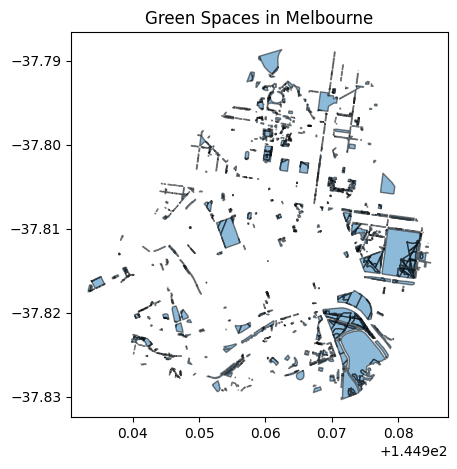

In [32]:
# Reset index for clean DataFrame
gdf_spaces_coveringPolys.reset_index(drop=True, inplace=True)

# Initialize GeoDF to which relevant green space data points will be concatenated
greenspace_within = gpd.GeoDataFrame(columns=gdf_spaces_coveringPolys.columns, crs="EPSG:4326")

# Merge fetched green space with space inside isochrones
for key, value in graphs_dict.items():
    polygon = value['geometry']
    # Convert polygon to GeoDF
    poly_gdf = gpd.GeoDataFrame([1], geometry=[polygon], crs="EPSG:4326")
    poly_gdf['preserved_geom'] = poly_gdf.geometry
    # Get the green space(s) within the polygon
    greenspace_iter = gdf_spaces_coveringPolys.sjoin(poly_gdf, predicate='intersects')
    greenspace_within = pd.concat([greenspace_within, greenspace_iter], ignore_index=True)

# Compute the intersection of the geometries
greenspace_within['intersection'] = greenspace_within.apply(lambda row: row['geometry'].intersection(row['preserved_geom']), axis=1)

# Filter to retain only valid intersections
valid_intersections = greenspace_within[greenspace_within['intersection'].is_empty == False]

# Function to resolve overlapping geometries using overlay
def resolve_overlaps(gdf):
    resolved = gpd.GeoDataFrame(columns=gdf.columns, crs=gdf.crs)
    while not gdf.empty:

        geom = gdf.iloc[0]
        others = gdf.iloc[1:]
        # Compute the difference
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="`keep_geom_type=True` in overlay resulted in")
            # Run your overlay code here
            geom_diff = gpd.overlay(
                gpd.GeoDataFrame([geom], columns=gdf.columns, crs="EPSG:4326"), 
                others, 
                how='difference'
            )
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=FutureWarning) 
            resolved = pd.concat([resolved, geom_diff], ignore_index=True)
        gdf = others
    return resolved

# Create a new GeoDataFrame with the intersections, drop duplicate elements
greenspace_osm = gpd.GeoDataFrame(valid_intersections.drop(columns='geometry').rename(columns={'intersection': 'geometry'}),
                                   geometry='geometry', crs=greenspace_within.crs)
greenspace_osm = greenspace_osm.drop_duplicates(subset='geometry')

# Ensure that we filter out any non-polygon geometries right before running overlay
greenspace_osm = greenspace_osm[greenspace_osm.geometry.geom_type == 'Polygon']
# Resolve overlaps in the geometries
greenspace_osm_resolved = resolve_overlaps(greenspace_osm)

greenspace_osm_resolved.plot(figsize=(5, 5), alpha=0.5, edgecolor='k')
plt.title('Green Spaces in Melbourne')
plt.show()

In [12]:
data_list_greens = []

# Loop through each polygon in the graph_dict
for key, value in graphs_dict.items():
    polygon = value['geometry']
    poly_gdf = gpd.GeoDataFrame([1], geometry=[polygon], crs="EPSG:4326")
    
    # Get the greenspace (NOT including street trees) within the polygon
    greenery_gdf = greenspace_osm_resolved.drop(['index_right', 'preserved_geom'], axis=1).sjoin(poly_gdf, predicate='intersects')
    
    # Reproject the geometries to Irish Transverse Mercator (EPSG:2157) for accurate area calculations
    greenery_gdf = greenery_gdf.to_crs(epsg=2157)
    
    # Calculate the area of each leisure and add a new column 'Area (m²)'
    greenery_gdf['Area (m²)'] = greenery_gdf.geometry.area
    
    # Calculate the total green area within the current polygon
    total_greens_area = greenery_gdf['Area (m²)'].sum()
    
    # Append the data for the current leisure type and polygon to the green list
    data_list_greens.append([key, total_greens_area])

# Create a DataFrame from the collected data
green_area_df = pd.DataFrame(data_list_greens, columns=['Polygon', 'Total Area (m²)'])
print(green_area_df.head())

  Polygon  Total Area (m²)
0   G_000    278857.588745
1   G_001    653724.674071
2   G_002    575820.007990
3   G_003     81712.874587
4   G_004    110968.409946


## **Tree areas** (based on City of Melbourne data)
Data can be downloaded from https://data.melbourne.vic.gov.au/explore/dataset/tree-canopies-public-realm-2018-urban-forest/export/

In [11]:
# Import urban tree canopy data from City of Melbourne
tree_canopy = gpd.read_file(os.path.join(open_data_dir,'tree-canopies-public-realm-2018-urban-forest.geojson'))
tree_canopy = tree_canopy.set_crs("EPSG:4326")

In [12]:
# Merge fetched trees with space inside isochrones
# **NOTE** Took 10min to run on Kanaha's laptop
treespace_within = gpd.GeoDataFrame(columns=gdf_spaces_coveringPolys.columns, crs="EPSG:4326")

for key, value in graphs_dict.items():
    polygon = value['geometry']
    # Convert polygon to GeoDF
    poly_gdf = gpd.GeoDataFrame([1], geometry=[polygon], crs="EPSG:4326")
    poly_gdf['preserved_geom'] = poly_gdf.geometry
    # Get the green space(s) within the polygon
    greenspace_iter = tree_canopy.sjoin(poly_gdf, predicate='intersects')
    greenspace_iter['Polygon'] = key
    treespace_within = pd.concat([treespace_within, greenspace_iter], ignore_index=True)

In [13]:
# Compute the intersection of the geometries
treespace_within['intersection'] = treespace_within.apply(lambda row: row['geometry'].intersection(row['preserved_geom']), axis=1)

# Filter to retain only valid intersections
valid_intersections = treespace_within[treespace_within['intersection'].is_empty == False]

# Create a new GeoDataFrame with the intersections
trees_final = gpd.GeoDataFrame(valid_intersections.drop(columns='geometry').rename(columns={'intersection': 'geometry'}), 
                               geometry='geometry', crs=treespace_within.crs)

In [14]:
# Save tree cover data to GeoJSON
trees_final.columns = trees_final.columns.astype(str)

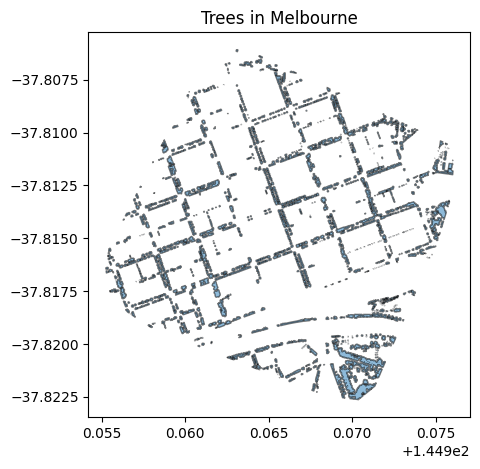

In [15]:
# Plot the trees for an example polygon
trees_final.loc[trees_final['Polygon']=='G_000'].plot(figsize=(5, 5), alpha=0.5, edgecolor='k')
plt.title('Trees in Melbourne')
plt.show()

In [16]:
# Create an empty list to store the data for each polygon
data_list = []

# Create copy of trees_final, reproject geometry for area calculations
trees_iter = trees_final.to_crs(epsg=2157)

# Loop through each polygon in the graph_dict
for key, value in graphs_dict.items():
    polygon = value['geometry']
    # Get area of each tree polygon in isochrone and sum
    trees_area_poly = trees_iter.loc[trees_iter['Polygon']==key].geometry.area.sum()
    # Append the data for the current building type and polygon to the list
    data_list.append([key, trees_area_poly])

# Create the tree_areas_df DataFrame from the list of data
tree_areas_df = pd.DataFrame(data_list, columns=['Polygon', 'Total Area (m²)'])
print(tree_areas_df.head())

  Polygon  Total Area (m²)
0   G_000    221009.532816
1   G_001    294634.421434
2   G_002    237674.569212
3   G_003     11935.709458
4   G_004     70404.162667


## **Network statistics** (based on OSM)

In [17]:
# Create an empty list to store the data
stats_df = []

# Iterate through the graphs in graphs_dict and calculate stats
for key, value in graphs_dict.items():
    stats = ox.stats.basic_stats(value['graph'], area=None, clean_int_tol=None)
    stats['Polygon'] = key
    stats_df.append(stats)

# Create a DataFrame from the list of dictionaries
network_stats = pd.DataFrame(stats_df)

print(network_stats.head())

      n     m     k_avg  edge_length_total  edge_length_avg  \
0  3201  8573  5.356451         227395.618        26.524626   
1  3573  9583  5.364120         259334.053        27.061886   
2  2662  6957  5.226897         195361.472        28.081281   
3   616  1579  5.126623          61710.713        39.082149   
4  1643  4265  5.191722         138364.882        32.441942   

   streets_per_node_avg                            streets_per_node_counts  \
0              3.222118  {0: 0, 1: 405, 2: 2, 3: 1309, 4: 1457, 5: 19, ...   
1              3.228380  {0: 0, 1: 437, 2: 3, 3: 1492, 4: 1601, 5: 29, ...   
2              3.176559  {0: 0, 1: 355, 2: 7, 3: 1143, 4: 1134, 5: 16, ...   
3              3.118506    {0: 0, 1: 70, 2: 3, 3: 333, 4: 205, 5: 4, 6: 1}   
4              3.184419   {0: 0, 1: 199, 2: 9, 3: 732, 4: 697, 5: 5, 6: 1}   

                        streets_per_node_proportions  intersection_count  \
0  {0: 0.0, 1: 0.12652296157450796, 2: 0.00062480...                2796   


## **Footpath length** (based on DATA VIC)
Data can be downloaded from https://discover.data.vic.gov.au/dataset/footpaths

In [18]:
# Import footpaths file
footpaths = gpd.read_file(os.path.join(open_data_dir,'footpaths.geojson')).to_crs("EPSG:2157")

In [19]:
# Function to dissolve multipolygons into a single Polygon - for solving issues encountered later in path GDF
def dissolve_multipolygon(geometry):
    if isinstance(geometry, MultiPolygon):
        dissolved_polygon = geometry.convex_hull
        return dissolved_polygon
    return geometry

In [20]:
# Function to calculate the maximum distance between points on the convex hull
def max_end_to_end_length(polygon):
    # Extract the boundary points
    points = np.array(polygon.exterior.coords)
    # Calculate the convex hull
    hull = ConvexHull(points)
    hull_points = points[hull.vertices]
    # Calculate the maximum distance between any two points on the convex hull
    max_distance = 0
    for i in range(len(hull_points)):
        for j in range(i+1, len(hull_points)):
            distance = np.linalg.norm(hull_points[i] - hull_points[j])
            if distance > max_distance:
                max_distance = distance
    return max_distance

In [21]:
# Apply the function to dissolve MultiPolygon into a single Polygon
footpaths['geometry'] = footpaths['geometry'].apply(dissolve_multipolygon)

# Calculate the longest end-to-end length for each polygon
footpaths['max_end_to_end_length'] = footpaths.geometry.apply(max_end_to_end_length)

In [22]:
# Initialize an empty list to store the results
df_paths = []

footpaths.columns

for key, value in graphs_dict.items():
    polygon = value['geometry']
    # Convert polygon to GeoDF
    poly_gdf = gpd.GeoDataFrame([1], geometry=[polygon], crs="EPSG:4326")
    poly_gdf = poly_gdf.to_crs("EPSG:2157")
    poly_gdf['preserved_geom'] = poly_gdf.geometry

    # Get the jobs within the polygon, sum
    path_iter = poly_gdf.sjoin(footpaths, predicate='intersects')
    path_iter = path_iter.drop(columns=['preserved_geom', 'geometry', 'last_edi_1', 'last_edite', 'created_us', 'created_da', 'xdate'])
    # Convert all columns to numeric, non-convertible values will be set to NaN
    path_iter = path_iter.apply(pd.to_numeric, errors='coerce')
    sum_df = path_iter.sum(axis=0).to_frame().transpose()
    df_paths.append([key, sum_df['max_end_to_end_length'][0]])

walkable_length_df = pd.DataFrame(df_paths, columns=['Polygon', 'Total length (m)'])
print(walkable_length_df.head())

  Polygon  Total length (m)
0   G_000      85167.267260
1   G_001      98030.146736
2   G_002      77106.364107
3   G_003      16802.674037
4   G_004      58659.257439


## **Public transport access** (based on DATA VIC & City of Melbourne data)
PTV Metro Bus Stops data can be downloaded from https://discover.data.vic.gov.au/dataset/ptv-metro-bus-stops<br>
Metro train stations with accessibility informatinon data can be downloaded from https://data.melbourne.vic.gov.au/explore/dataset/metro-train-stations-with-accessibility-information/export/<br>
PTV Metro Tram Stops data can be downloaded from https://discover.data.vic.gov.au/dataset/ptv-metro-tram-stops

In [23]:
# Import public transit stop GeoDFs
bus_stops = gpd.read_file(os.path.join(open_data_dir,'PTV_METRO_BUS_STOP.shp')).to_crs("EPSG:4326")
train_stops = gpd.read_file(os.path.join(open_data_dir,'metro-train-stations-with-accessibility-information.geojson')).to_crs("EPSG:4326")
tram_stops = gpd.read_file(os.path.join(open_data_dir,'PTV_METRO_TRAM_STOP.shp')).to_crs("EPSG:4326")

In [24]:
# Get counts of number of stops per type per polygon
# Initialize an empty list to store the results
df_stops = []

for key, value in graphs_dict.items():
    polygon = value['geometry']
    # Convert polygon to GeoDF
    poly_gdf = gpd.GeoDataFrame([1], geometry=[polygon], crs="EPSG:4326")
    poly_gdf['preserved_geom'] = poly_gdf.geometry

    # Get the stop(s) within the polygon
    bus_iter = poly_gdf.sjoin(bus_stops, predicate='covers')
    tram_iter = poly_gdf.sjoin(tram_stops, predicate='covers')
    train_iter = poly_gdf.sjoin(train_stops, predicate='covers')

    df_stops.append([key, len(bus_iter) + len(tram_iter) + len(train_iter), len(bus_iter), len(tram_iter), len(train_iter)])

# Create the DataFrame from the list of data
public_transport_access_df = pd.DataFrame(df_stops, columns=['Polygon', 'Total Transit Stop Count', 'Bus Count', 'Tram Count', 'Train Count'])
print(public_transport_access_df.head())

  Polygon  Total Transit Stop Count  Bus Count  Tram Count  Train Count
0   G_000                       111         35          73            3
1   G_001                       114         36          75            3
2   G_002                        94         28          65            1
3   G_003                        13          8           5            0
4   G_004                        52         11          40            1


## **Lamp counts** (based on DATA VIC data)
Data can be downloaded from https://discover.data.vic.gov.au/dataset/street-lights-with-emitted-lux-level-council-owned-lights-only

In [25]:
# # Import street lamps DF
lamps_gdf = gpd.read_file(os.path.join(open_data_dir,'street-lights-with-emitted-lux-level-council-owned-lights-only.geojson')).to_crs("EPSG:4326")

In [26]:
df_lamps = []

for key, value in graphs_dict.items():
    polygon = value['geometry']
    # Convert polygon to GeoDF
    poly_gdf = gpd.GeoDataFrame([1], geometry=[polygon], crs="EPSG:4326")
    poly_gdf['preserved_geom'] = poly_gdf.geometry

    # Get the lamps within the polygon
    lamps_iter = poly_gdf.sjoin(lamps_gdf, predicate='intersects')
    lamps_iter['Polygon'] = key
    lamps_iter = lamps_iter.drop(columns=['preserved_geom', 'geometry'])
    
    # Count the number of lamps
    lamps_count = len(lamps_iter)
    
    df_lamps.append([key, lamps_count])

# Convert to DataFrame
lamp_counts_df = pd.DataFrame(df_lamps, columns=['Polygon', 'Lamps in Block'])
print(lamp_counts_df.head())

  Polygon  Lamps in Block
0   G_000           16911
1   G_001           21286
2   G_002           16405
3   G_003            4539
4   G_004           23927


## **Bench counts** (based on DATA VIC data)
Data can be downloaded from https://discover.data.vic.gov.au/dataset/street-furniture-including-bollards-bicycle-rails-bins-drinking-fountains-horse-troughs-planter

In [27]:
# Import street furniture DF
furniture_gdf = gpd.read_file(os.path.join(open_data_dir,'street-furniture-including-bollards-bicycle-rails-bins-drinking-fountains-horse-.geojson')).to_crs("EPSG:4326")

# Drop non-seating furniture
furniture_gdf = furniture_gdf.loc[(furniture_gdf['asset_type'] == 'Seat') | (furniture_gdf['asset_type'] == 'Picnic Setting')]

In [28]:
df_furniture = []

for key, value in graphs_dict.items():
    polygon = value['geometry']
    # Convert polygon to GeoDF
    poly_gdf = gpd.GeoDataFrame([1], geometry=[polygon], crs="EPSG:4326")
    poly_gdf['preserved_geom'] = poly_gdf.geometry

    # Get the seats within the polygon
    seats_iter = poly_gdf.sjoin(furniture_gdf, predicate='intersects')
    seats_iter['Polygon'] = key
    seats_iter = seats_iter.drop(columns=['preserved_geom', 'geometry'])
    
    # Count the number of seats
    seats_count = len(seats_iter)
    
    df_furniture.append([key, seats_count])

# Convert to DataFrame
public_furniture_counts_df = pd.DataFrame(df_furniture, columns=['Polygon', 'Seats in Block'])
print(public_furniture_counts_df.head())

  Polygon  Seats in Block
0   G_000             756
1   G_001             885
2   G_002             670
3   G_003             168
4   G_004             500


### Export the dataframes as csv

In [29]:
print(green_area_df.head())
print(tree_areas_df.head())
print(network_stats.head())
print(walkable_length_df.head())
print(public_transport_access_df.head())
print(lamp_counts_df.head())
print(public_furniture_counts_df.head())

  Polygon  Total Area (m²)
0   G_000    278857.588745
1   G_001    653724.674071
2   G_002    575820.007990
3   G_003     81712.874587
4   G_004    110968.409946
  Polygon  Total Area (m²)
0   G_000    221009.532816
1   G_001    294634.421434
2   G_002    237674.569212
3   G_003     11935.709458
4   G_004     70404.162667
      n     m     k_avg  edge_length_total  edge_length_avg  \
0  3201  8573  5.356451         227395.618        26.524626   
1  3573  9583  5.364120         259334.053        27.061886   
2  2662  6957  5.226897         195361.472        28.081281   
3   616  1579  5.126623          61710.713        39.082149   
4  1643  4265  5.191722         138364.882        32.441942   

   streets_per_node_avg                            streets_per_node_counts  \
0              3.222118  {0: 0, 1: 405, 2: 2, 3: 1309, 4: 1457, 5: 19, ...   
1              3.228380  {0: 0, 1: 437, 2: 3, 3: 1492, 4: 1601, 5: 29, ...   
2              3.176559  {0: 0, 1: 355, 2: 7, 3: 1143, 4: 1134,

In [30]:
#  DATA EXPORT STATEMENTS
if isochorne_type == 15:
    area_df.to_csv(os.path.join(output_dir,'15min_melbourne_area_df.csv'),index=False) 
    green_area_df.to_csv(os.path.join(output_dir,'15min_melbourne_green_area_df.csv'),index=False) 
    tree_areas_df.to_csv(os.path.join(output_dir,'15min_melbourne_tree_areas_df.csv'),index=False) 
    network_stats.to_csv(os.path.join(output_dir,'15min_melbourne_network_stats_df.csv'),index=False)
    walkable_length_df.to_csv(os.path.join(output_dir,'15min_melbourne_walkable_length_df.csv'),index=False) 
    public_transport_access_df.to_csv(os.path.join(output_dir,'15min_melbourne_public_transport_access_df.csv'),index=False) 
    lamp_counts_df.to_csv(os.path.join(output_dir,'15min_melbourne_lamp_counts_df.csv'),index=False) 
    public_furniture_counts_df.to_csv(os.path.join(output_dir,'15min_melbourne_public_seating_df.csv'),index=False) 

if isochorne_type == 5:
    area_df.to_csv(os.path.join(output_dir,'5min_melbourne_area_df.csv'),index=False) 
    green_area_df.to_csv(os.path.join(output_dir,'5min_melbourne_green_area_df.csv'),index=False) 
    tree_areas_df.to_csv(os.path.join(output_dir,'5min_melbourne_tree_areas_df.csv'),index=False) 
    network_stats.to_csv(os.path.join(output_dir,'5min_melbourne_network_stats_df.csv'),index=False)
    walkable_length_df.to_csv(os.path.join(output_dir,'5min_melbourne_walkable_length_df.csv'),index=False) 
    public_transport_access_df.to_csv(os.path.join(output_dir,'5min_melbourne_public_transport_access_df.csv'),index=False) 
    lamp_counts_df.to_csv(os.path.join(output_dir,'5min_melbourne_lamp_counts_df.csv'),index=False) 
    public_furniture_counts_df.to_csv(os.path.join(output_dir,'5min_melbourne_public_seating_df.csv'),index=False) 